In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.io import save_versioned, load_latest, raw_path, get_output_dir

# ============================================================
# CELL 1 – Cluster 4 – Setup and data loading
# ============================================================

# --- Library installation (not needed in venv) ---
print("Setting up environment...")
# --- Standard imports ---
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- sklearn imports ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier

# --- Import skfuzzy ---
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# --- Import tqdm ---
from tqdm.auto import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
output_dir = get_output_dir(4)
plt.rcParams['figure.figsize'] = (12, 5)

print("All libraries imported successfully.")

# --- Parametri globali ---
id_cols     = ['subject_id', 'hadm_id', 'stay_id',
               'ICU', 'ICU_intime', 'ICU_outtime']
outcome_col = 'outcome'
join_cols   = ['subject_id', 'hadm_id', 'stay_id']
cluster_col = 'cluster_id'
CLUSTER_ID  = 3   # ← Cluster B (Cluster 3 from 12x12 SOM, as selected by LAB3)

print(f"\n Global parameters:")
print(f"   → Selected cluster : {CLUSTER_ID}")
print(f"   → Outcome column      : {outcome_col}")
print(f"   → Random state        : {RANDOM_STATE}")


Setting up environment...


Output directory: LAB4/outputs/20260617_210824
All libraries imported successfully.

 Global parameters:
   → Selected cluster : 3
   → Outcome column      : outcome
   → Random state        : 42


In [2]:
# ─── Configuration ────────────────────────────────────────────────────────────
# DS_KEY: which LAB2 assignment to use ('3a','3b','3c','3d')
# Raw dataset is used so that individual comorbidity columns are available
DS_KEY   = '3a'
SOM_SIZE = '12x12'   # best SOM size as selected by LAB3

# Raw dataset (4000×120) — keeps all original columns including comorbidities
df_full      = pd.read_excel(str(raw_path('Dataset_DAPPC_2026.xlsx')),
                             sheet_name='Dataset')
assignment_df = load_latest(f'LAB2_assignments_knn_global_{SOM_SIZE}')

print(f'Raw dataset shape   : {df_full.shape}')
print(f'Assignment shape    : {assignment_df.shape}')


Loading → LAB2/outputs/20260617_210035/LAB2_assignments_knn_global_12x12.xlsx


Raw dataset shape   : (4000, 120)
Assignment shape    : (3893, 11)


In [3]:
# ─── Merge assignments + filter to Cluster 4 ─────────────────────────────────
id_cols     = ['subject_id', 'hadm_id', 'stay_id', 'ICU', 'ICU_intime', 'ICU_outtime']
outcome_col = 'outcome'
join_cols   = ['subject_id', 'hadm_id', 'stay_id']

df = df_full.merge(
    assignment_df[join_cols + ['cluster_id']], on=join_cols, how='inner'
)

# Cluster B (most distant from Cluster A) as determined by LAB3.
# 12x12 SOM: Cluster 3 (n=3344) is most distant from Cluster 2 (Cluster A).
TARGET_CLUSTER = 3
cluster_df = df[df['cluster_id'] == TARGET_CLUSTER].copy()

feature_cols = [c for c in df_full.columns if c not in id_cols + [outcome_col]]

print(f'Merged df shape    : {df.shape}')
print(f'Cluster {TARGET_CLUSTER} (B) shape: {cluster_df.shape}')
print(f'Outcome distribution:\n{cluster_df[outcome_col].value_counts().sort_index().to_string()}')


Merged df shape    : (3893, 121)
Cluster 3 (B) shape: (51, 121)
Outcome distribution:
outcome
0     9
1    32
2    10


In [4]:
# ============================================================
# CELL 3 – Cluster 4 – ACO-selected features
# ============================================================

# ── Random split (seed=42): Cluster B keeps 4 of the 8 ACO features ──
# first_plateau_pressure and std_mean_airway_pressure are removed from Cluster A
# and assigned to Cluster B; charlson_comorbidity_index and std_plateau_pressure
# are shared (taken from Cluster A) to complete Cluster B's 4 features.
selected_features_cluster4 = [
    'first_plateau_pressure',
    'std_mean_airway_pressure',
    'charlson_comorbidity_index',
    'std_plateau_pressure',
]

print(f'  Selected features for Cluster 4:')
for i, f in enumerate(selected_features_cluster4, 1):
    print(f'  {i:2d}. {f}')
print(f'  → Total features : {len(selected_features_cluster4)}')

# --- Prepara X e y ---
feature_cols_cluster4 = [
    c for c in selected_features_cluster4
    if c in cluster_df.columns
]

X_df = cluster_df[feature_cols_cluster4].copy()
y    = cluster_df[outcome_col].values

print(f"\n Matrice X e vettore y preparati!")
print(f"   → Shape X : {X_df.shape}")
print(f"   → Shape y : {y.shape}")
print(f"\n Distribuzione classi:")
display(pd.Series(y).value_counts().sort_index().rename({
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}))



  Selected features for Cluster 4:
   1. first_plateau_pressure
   2. std_mean_airway_pressure
   3. charlson_comorbidity_index
   4. std_plateau_pressure
  → Total features : 4

 Matrice X e vettore y preparati!
   → Shape X : (51, 4)
   → Shape y : (51,)

 Distribuzione classi:


0–Extubation Failure     9
1–Extubation Success    32
2–Death during ICU      10
Name: count, dtype: int64

In [5]:
# ============================================================
# CELL 4 – CLUSTER 4 – Imputazione e Scaling
# ============================================================

print(f"NaN in X_df prima dell'imputazione: "
      f"{X_df.isna().sum().sum()}")

# --- Imputazione con mediana ---
imputer       = SimpleImputer(strategy='median')
X_imputed_arr = imputer.fit_transform(X_df)
X_imputed     = pd.DataFrame(
    X_imputed_arr,
    columns=feature_cols_cluster4,
    index=X_df.index
)

print(f"NaN dopo imputazione: "
      f"{X_imputed.isna().sum().sum()}")

# ── LAB4 spec: membership functions are built on the COMPLETE dataset ──
# (all subjects, every cluster), not on the single-cluster subset.
X_full_imputed = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df_full[feature_cols_cluster4]),
    columns=feature_cols_cluster4,
    index=df_full.index
)
print(f"Matrice completa per costruzione MF: {X_full_imputed.shape}")

# --- Scaling Min-Max ---
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\n Imputazione e scaling completati!")
print(f"   → Shape X_imputed : {X_imputed.shape}")
print(f"   → Shape X_scaled  : {X_scaled.shape}")

# --- Statistiche descrittive ---
print(f"\n Statistiche descrittive (spazio reale):")
display(X_imputed.describe().round(3))



NaN in X_df prima dell'imputazione: 0
NaN dopo imputazione: 0
Matrice completa per costruzione MF: (4000, 4)

 Imputazione e scaling completati!
   → Shape X_imputed : (51, 4)
   → Shape X_scaled  : (51, 4)

 Statistiche descrittive (spazio reale):


,first_plateau_pressure,std_mean_airway_pressure,charlson_comorbidity_index,std_plateau_pressure
count,51.000,51.000,51.000,51.000
mean,18.524,2.528,4.137,2.607
std,4.650,1.896,2.980,2.096
min,12.000,0.398,0.000,0.000
25%,15.000,1.471,2.000,1.706
50%,17.000,2.134,4.000,2.165
75%,20.500,3.150,5.000,3.085
max,30.000,12.670,11.000,14.056


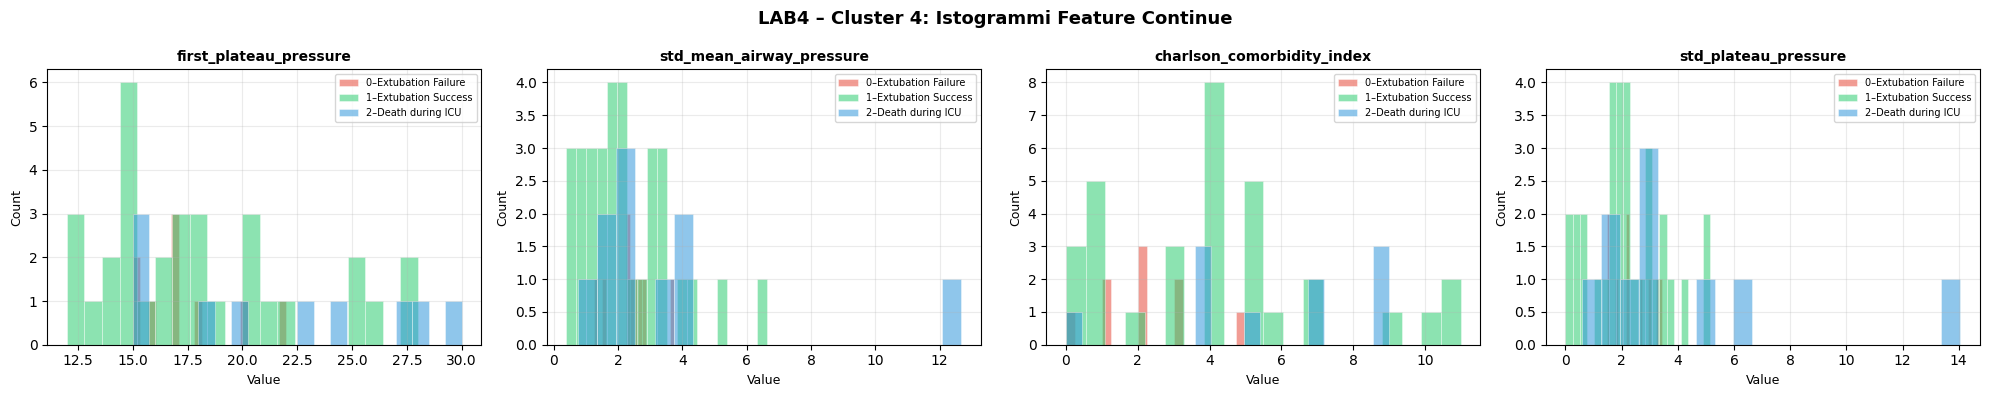

 Istogrammi salvati in 'histograms_cluster4.png'


In [6]:
# ============================================================
# CELL 5 – Cluster 4 – Feature histograms
# ============================================================

labels_class = {
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}
colors_class = {
    0: '#e74c3c',
    1: '#2ecc71',
    2: '#3498db'
}

continuous_features = [
    'first_plateau_pressure',
    'std_mean_airway_pressure',
    'charlson_comorbidity_index',
    'std_plateau_pressure'
]
binary_features = []

n_cont = len(continuous_features)
fig, axes = plt.subplots(1, n_cont, figsize=(20, 4))

for ax, feat in zip(axes, continuous_features):
    for c in [0, 1, 2]:
        mask   = y == c
        values = X_imputed.loc[
            X_imputed.index[mask], feat
        ]
        ax.hist(values, bins=20, alpha=0.55,
                color=colors_class[c],
                label=labels_class[c],
                edgecolor='white', linewidth=0.5)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    'LAB4 – Cluster 4: Istogrammi Feature Continue',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(output_dir / 'histograms_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Istogrammi salvati in 'histograms_cluster4.png'")


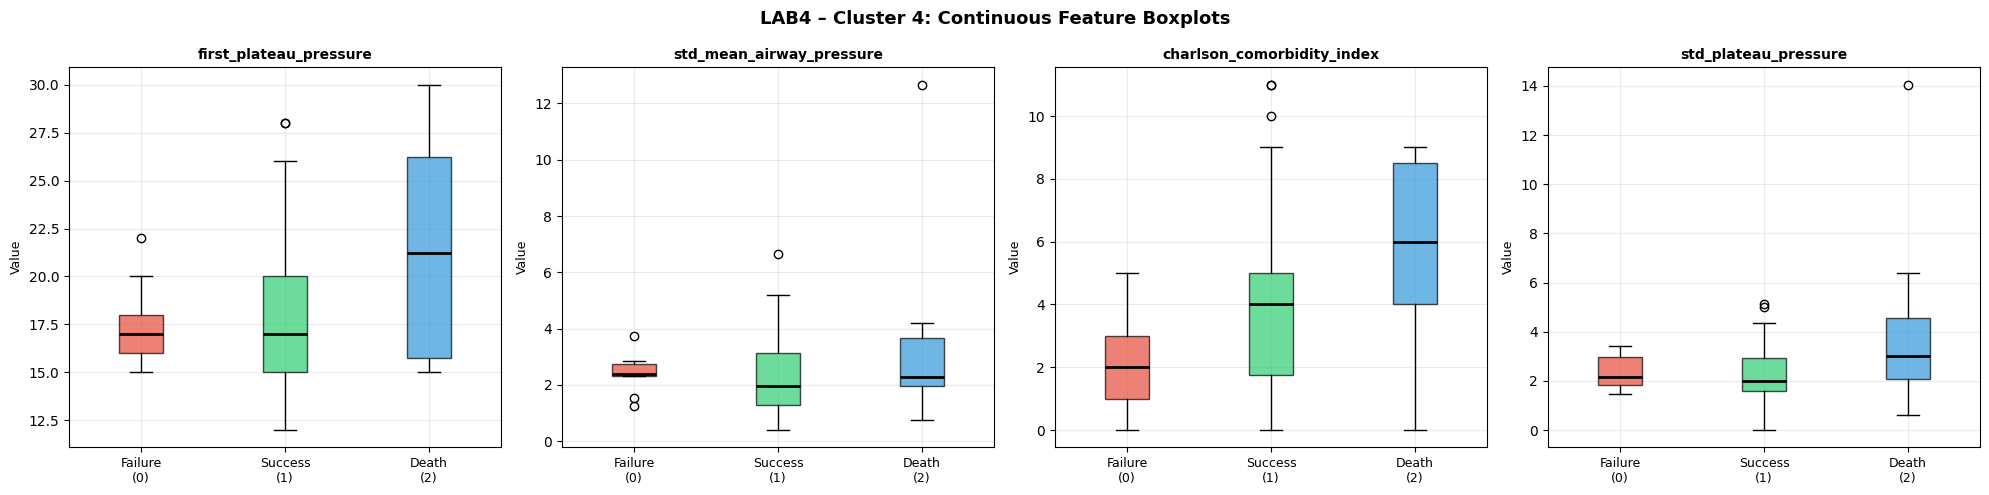

 Boxplot salvati in 'boxplots_cluster4.png'


In [7]:
# ============================================================
# CELL 6 – Cluster 4 – Boxplots
# ============================================================

fig, axes = plt.subplots(1, n_cont, figsize=(20, 5))

for ax, feat in zip(axes, continuous_features):
    data_box = [
        X_imputed.loc[
            X_imputed.index[y == c], feat
        ].values
        for c in [0, 1, 2]
    ]
    bp = ax.boxplot(data_box, patch_artist=True,
                    medianprops=dict(color='black',
                                    linewidth=2))
    for patch, c in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(colors_class[c])
        patch.set_alpha(0.7)

    ax.set_xticklabels(
        ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
        fontsize=9
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    'LAB4 – Cluster 4: Continuous Feature Boxplots',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(output_dir / 'boxplots_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Boxplot salvati in 'boxplots_cluster4.png'")


In [8]:
# ============================================================
# CELL 7 – CLUSTER 4 – Definizione Universi Fuzzy
# ============================================================

# --- Range reali dal dataset COMPLETO (LAB4 spec) ---
u_plateau  = np.linspace(
    X_full_imputed['first_plateau_pressure'].min(),
    X_full_imputed['first_plateau_pressure'].max(), 200)
u_charlson = np.linspace(
    X_full_imputed['charlson_comorbidity_index'].min(),
    X_full_imputed['charlson_comorbidity_index'].max(), 200)
u_map      = np.linspace(
    X_full_imputed['std_mean_airway_pressure'].min(),
    X_full_imputed['std_mean_airway_pressure'].max(), 200)
u_plat_std = np.linspace(
    X_full_imputed['std_plateau_pressure'].min(),
    X_full_imputed['std_plateau_pressure'].max(), 200)
u_risk     = np.linspace(0, 100, 200)

print(" Universi fuzzy definiti per Cluster 4:")
print(f"   → plateau_pressure : "
      f"[{u_plateau.min():.2f}, {u_plateau.max():.2f}]")
print(f"   → charlson_index   : "
      f"[{u_charlson.min():.2f}, {u_charlson.max():.2f}]")
print(f"   → std_map          : "
      f"[{u_map.min():.2f}, {u_map.max():.2f}]")
print(f"   → std_plateau      : "
      f"[{u_plat_std.min():.2f}, {u_plat_std.max():.2f}]")


 Universi fuzzy definiti per Cluster 4:
   → plateau_pressure : [0.00, 46.00]
   → charlson_index   : [0.00, 19.00]
   → std_map          : [0.00, 22.44]
   → std_plateau      : [0.00, 40.86]


In [9]:
# ============================================================
# CELL 8 – CLUSTER 4 – Antecedenti, Conseguente e Percentili
# ============================================================

# --- Antecedenti (feature continue) ---
plateau  = ctrl.Antecedent(
    u_plateau,  'first_plateau_pressure')
charlson = ctrl.Antecedent(
    u_charlson, 'charlson_comorbidity_index')
std_map  = ctrl.Antecedent(
    u_map,      'std_mean_airway_pressure')
std_plat = ctrl.Antecedent(
    u_plat_std, 'std_plateau_pressure')

# --- Conseguente ---
clinical_risk = ctrl.Consequent(u_risk, 'clinical_risk')

# --- Percentili adattivi al Cluster 4 ---
def get_percentiles(series):
    return (series.quantile(0.25),
            series.quantile(0.50),
            series.quantile(0.75))

p25_pl, p50_pl, p75_pl = get_percentiles(
    X_full_imputed['first_plateau_pressure'])
p25_ch, p50_ch, p75_ch = get_percentiles(
    X_full_imputed['charlson_comorbidity_index'])
p25_mp, p50_mp, p75_mp = get_percentiles(
    X_full_imputed['std_mean_airway_pressure'])
p25_sp, p50_sp, p75_sp = get_percentiles(
    X_full_imputed['std_plateau_pressure'])

print(" Percentili calcolati per Cluster 4:")
print(f"   plateau_pressure → "
      f"Q1={p25_pl:.2f} Q2={p50_pl:.2f} Q3={p75_pl:.2f}")
print(f"   charlson_index   → "
      f"Q1={p25_ch:.2f} Q2={p50_ch:.2f} Q3={p75_ch:.2f}")
print(f"   std_map          → "
      f"Q1={p25_mp:.2f} Q2={p50_mp:.2f} Q3={p75_mp:.2f}")
print(f"   std_plateau      → "
      f"Q1={p25_sp:.2f} Q2={p50_sp:.2f} Q3={p75_sp:.2f}")


 Percentili calcolati per Cluster 4:
   plateau_pressure → Q1=16.00 Q2=19.00 Q3=23.00
   charlson_index   → Q1=2.00 Q2=4.00 Q3=6.00
   std_map          → Q1=1.48 Q2=2.32 Q3=3.29
   std_plateau      → Q1=1.37 Q2=2.21 Q3=3.19


In [10]:
# ============================================================
# CELL 9 – CLUSTER 4 – Definizione Membership Functions
# ============================================================

# ── plateau_pressure ──
plateau['low']    = fuzz.trapmf(u_plateau,
    [u_plateau.min(), u_plateau.min(), p25_pl, p50_pl])
plateau['normal'] = fuzz.trimf(u_plateau,
    [p25_pl, p50_pl, p75_pl])
plateau['high']   = fuzz.trapmf(u_plateau,
    [p50_pl, p75_pl, u_plateau.max(), u_plateau.max()])

# ── charlson_comorbidity_index ──
charlson['low']    = fuzz.trapmf(u_charlson,
    [u_charlson.min(), u_charlson.min(), p25_ch, p50_ch])
charlson['medium'] = fuzz.trimf(u_charlson,
    [p25_ch, p50_ch, p75_ch])
charlson['high']   = fuzz.trapmf(u_charlson,
    [p50_ch, p75_ch, u_charlson.max(), u_charlson.max()])

# ── std_mean_airway_pressure ──
std_map['stable']   = fuzz.trapmf(u_map,
    [u_map.min(), u_map.min(), p25_mp, p50_mp])
std_map['variable'] = fuzz.trimf(u_map,
    [p25_mp, p50_mp, p75_mp])
std_map['unstable'] = fuzz.trapmf(u_map,
    [p50_mp, p75_mp, u_map.max(), u_map.max()])

# ── std_plateau_pressure ──
std_plat['stable']   = fuzz.trapmf(u_plat_std,
    [u_plat_std.min(), u_plat_std.min(), p25_sp, p50_sp])
std_plat['variable'] = fuzz.trimf(u_plat_std,
    [p25_sp, p50_sp, p75_sp])
std_plat['unstable'] = fuzz.trapmf(u_plat_std,
    [p50_sp, p75_sp, u_plat_std.max(), u_plat_std.max()])

# ── Output clinical_risk ──
clinical_risk['low']    = fuzz.trapmf(u_risk,
    [0,  0,  25, 40])
clinical_risk['medium'] = fuzz.trimf(u_risk,
    [30, 50, 70])
clinical_risk['high']   = fuzz.trapmf(u_risk,
    [60, 75, 100, 100])

print(" Membership Functions definite per Cluster 4!")
print(f"   → plateau    : low / normal / high")
print(f"   → charlson   : low / medium / high")
print(f"   → std_map    : stable / variable / unstable")
print(f"   → std_plat   : stable / variable / unstable")
print(f"   → output     : low / medium / high")


 Membership Functions definite per Cluster 4!
   → plateau    : low / normal / high
   → charlson   : low / medium / high
   → std_map    : stable / variable / unstable
   → std_plat   : stable / variable / unstable
   → output     : low / medium / high


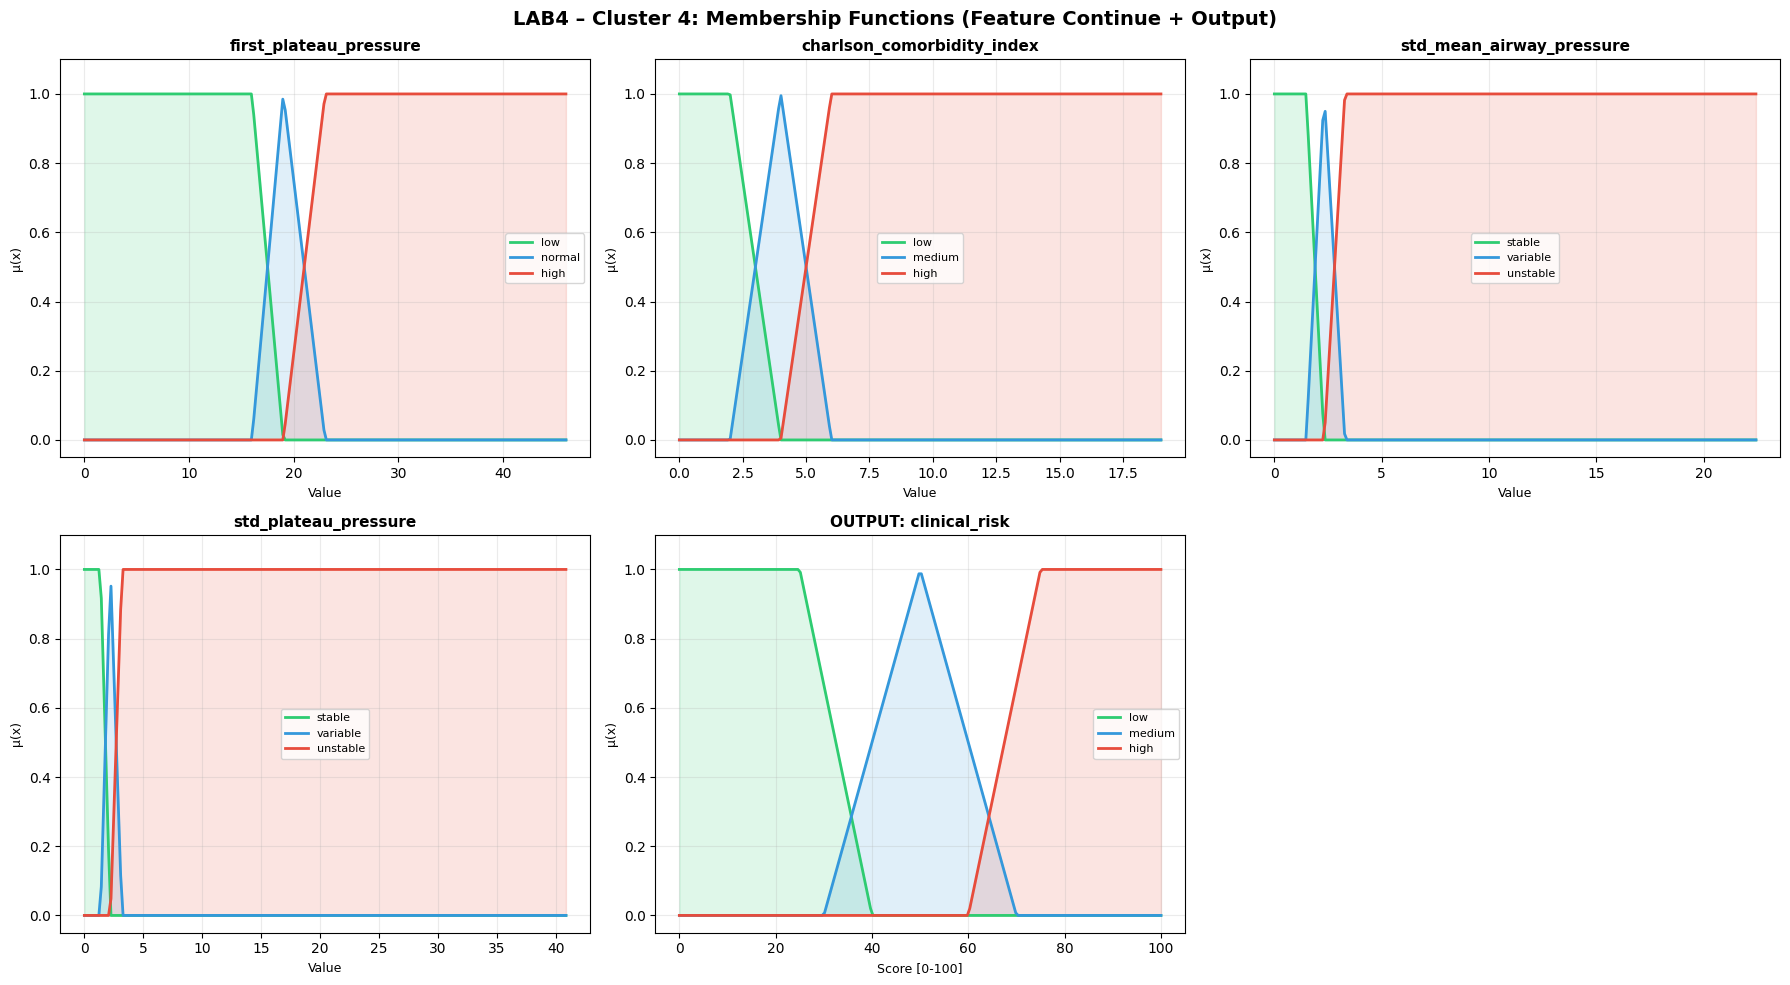

 MF continue salvate in 'MF_continuous_cluster4.png'


In [11]:
# ============================================================
# CELL 10 – Cluster 4 – Continuous MF + Output visualisation
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

mf_continuous = [
    (plateau,  'first_plateau_pressure',
     ['low','normal','high']),
    (charlson, 'charlson_comorbidity_index',
     ['low','medium','high']),
    (std_map,  'std_mean_airway_pressure',
     ['stable','variable','unstable']),
    (std_plat, 'std_plateau_pressure',
     ['stable','variable','unstable']),
    (clinical_risk, 'OUTPUT: clinical_risk',
     ['low','medium','high']),
]
colors_mf = ['#2ecc71', '#3498db', '#e74c3c']

for ax, (var, title, terms) in \
        zip(axes, mf_continuous):
    for term, color in zip(terms, colors_mf):
        ax.plot(var.universe, var[term].mf,
                color=color, linewidth=2, label=term)
        ax.fill_between(var.universe, var[term].mf,
                        alpha=0.15, color=color)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(
        'Value' if title != 'OUTPUT: clinical_risk'
        else 'Score [0-100]', fontsize=9)
    ax.set_ylabel('μ(x)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_ylim([-0.05, 1.1])

# Hide any unused axes (grid has 6 slots, we use len(mf_continuous))
for ax in axes[len(mf_continuous):]:
    ax.set_visible(False)

fig.suptitle(
    'LAB4 – Cluster 4: Membership Functions '
    '(Feature Continue + Output)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(output_dir / 'MF_continuous_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" MF continue salvate in "
      "'MF_continuous_cluster4.png'")


In [12]:
# ============================================================
# CELL 11 – Cluster 4 – Binary MF visualisation
# ============================================================

if binary_features:
    fig, axes = plt.subplots(1, len(binary_features),
                             figsize=(5 * len(binary_features), 4))
    if len(binary_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, binary_features):
        var = fuzzy_vars[feat]
        ax.plot(var.universe, var['absent'].mf,
                color='#2ecc71', linewidth=2.5, label='absent')
        ax.fill_between(var.universe, var['absent'].mf,
                        alpha=0.15, color='#2ecc71')
        ax.plot(var.universe, var['present'].mf,
                color='#e74c3c', linewidth=2.5, label='present')
        ax.fill_between(var.universe, var['present'].mf,
                        alpha=0.15, color='#e74c3c')
        ax.set_title(feat, fontsize=11, fontweight='bold')
        ax.set_xlabel('Value (0=No, 1=Yes)', fontsize=9)
        ax.set_ylabel('μ(x)', fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)
        ax.set_ylim([-0.05, 1.1])
    fig.suptitle(
        'LAB4 – Cluster 4: Membership Functions (Feature Binarie)',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(output_dir / 'MF_binary_cluster4.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(" MF binarie salvate in 'MF_binary_cluster4.png'")
else:
    print("Nessuna feature binaria nel Cluster B (split seed=42): "
          "step saltato.")


Nessuna feature binaria nel Cluster B (split seed=42): step saltato.


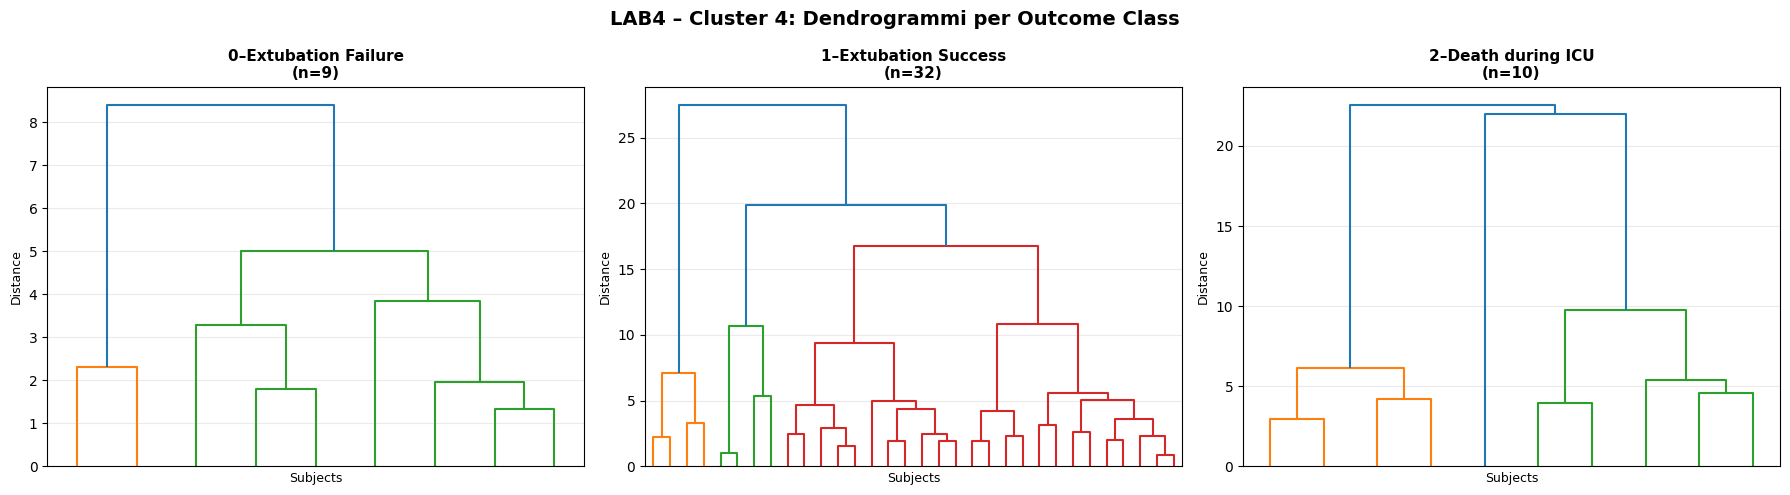

 Dendrogrammi salvati in 'dendrograms_cluster4.png'


In [13]:
# ============================================================
# CELL 12 – Cluster 4 – Dendrograms by Outcome Class
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, c in enumerate([0, 1, 2]):
    mask  = y == c
    X_sub = X_imputed[mask][continuous_features].values

    if len(X_sub) > 1:
        dist = pdist(X_sub, metric='euclidean')
        Z    = linkage(dist, method='ward')
        dendrogram(
            Z, ax=axes[idx],
            no_labels=True,
            color_threshold=0.7 * max(Z[:, 2])
        )
        axes[idx].set_title(
            f'{labels_class[c]}\n(n={mask.sum()})',
            fontsize=11, fontweight='bold'
        )
        axes[idx].set_xlabel('Subjects', fontsize=9)
        axes[idx].set_ylabel('Distance', fontsize=9)
        axes[idx].grid(True, alpha=0.25)

fig.suptitle(
    'LAB4 – Cluster 4: Dendrogrammi per Outcome Class',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(output_dir / 'dendrograms_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Dendrogrammi salvati in "
      "'dendrograms_cluster4.png'")


In [14]:
# ============================================================
# CELL 13 – CLUSTER 4 – Regole FIS da centroidi (LAB4-2 spec)
# ============================================================

from scipy.cluster.hierarchy import linkage, fcluster
import itertools

fuzzy_vars = {
    'first_plateau_pressure'    : plateau,
    'std_mean_airway_pressure'  : std_map,
    'charlson_comorbidity_index': charlson,
    'std_plateau_pressure'      : std_plat,
}
features_c4 = list(fuzzy_vars.keys())

# ── Prepara dati normalizzati per il clustering gerarchico ──
scaler_c4 = MinMaxScaler()
X_imputed_c4 = X_imputed[features_c4].copy()
X_scaled_c4 = pd.DataFrame(
    scaler_c4.fit_transform(X_imputed_c4),
    columns=features_c4,
    index=X_imputed_c4.index
)
X_scaled_c4[outcome_col] = cluster_df[outcome_col].values

classes_c4 = {
    0: '0 – Extubation Failure',
    1: '1 – Extubation Success',
    2: '2 – Death during ICU',
}
outcome_to_risk_c4 = {0: 'medium', 1: 'low', 2: 'high'}
n_clusters_per_class_c4 = {0: 2, 1: 3, 2: 3}

data_by_class_c4 = {}
linkage_matrices_c4 = {}
centroids_real_c4 = {}

for c in [0, 1, 2]:
    mask = X_scaled_c4[outcome_col] == c
    data_c = X_scaled_c4.loc[mask, features_c4].values
    data_by_class_c4[c] = data_c
    n_samples = data_c.shape[0]

    if n_samples == 0:
        # No subjects of this class in Cluster B → no rules generated.
        centroids_real_c4[c] = pd.DataFrame(columns=features_c4)
        continue

    if n_samples < 3:
        # Too few subjects for hierarchical clustering: use a single centroid
        # (the mean of the available subjects) as the class prototype.
        cents_norm = data_c.mean(axis=0, keepdims=True)
    else:
        Z = linkage(data_c, method='complete', metric='cityblock')
        linkage_matrices_c4[c] = Z
        n_k = min(n_clusters_per_class_c4[c], n_samples)
        labels = fcluster(Z, n_k, criterion='maxclust')
        cents_norm = np.array([
            data_c[labels == k].mean(axis=0)
            for k in range(1, n_k + 1)
            if (labels == k).sum() > 0
        ])

    cents_real = scaler_c4.inverse_transform(cents_norm)
    centroids_real_c4[c] = pd.DataFrame(
        cents_real,
        columns=features_c4,
        index=[f'C{c}_k{k+1}' for k in range(len(cents_real))]
    )

def get_best_mf_c4(value, fuzzy_var):
    best_term, best_mu = None, -1.0
    for term_name in fuzzy_var.terms:
        mu = fuzz.interp_membership(
            fuzzy_var.universe, fuzzy_var[term_name].mf, value)
        if mu > best_mu:
            best_mu, best_term = mu, term_name
    return best_term

# ── Regole automatiche dai centroidi denormalizzati ──
auto_rules_data_c4 = []
for c in [0, 1, 2]:
    for row_name, row in centroids_real_c4[c].iterrows():
        rule_dict = {feat: get_best_mf_c4(row[feat], fuzzy_vars[feat])
                     for feat in features_c4}
        rule_dict.update({
            'clinical_risk': outcome_to_risk_c4[c],
            'source': 'auto', 'class': c, 'centroid_id': row_name,
        })
        auto_rules_data_c4.append(rule_dict)

all_rules_data_c4 = list(auto_rules_data_c4)
for rule_d in auto_rules_data_c4:
    for fa, fb in itertools.combinations(features_c4, 2):
        all_rules_data_c4.append({
            fa: rule_d[fa], fb: rule_d[fb],
            'clinical_risk': rule_d['clinical_risk'],
            'source': 'pairwise',
            'class': rule_d['class'],
            'centroid_id': rule_d['centroid_id'] + '_pw',
        })

def build_antecedent_c4(rule_d, feats):
    ant = None
    for f in feats:
        if f not in rule_d:
            continue
        piece = fuzzy_vars[f][rule_d[f]]
        ant = piece if ant is None else ant & piece
    return ant

rules_cluster4 = []
seen_rules_c4 = set()
for rd in all_rules_data_c4:
    feats_in_rule = [f for f in features_c4 if f in rd]
    if not feats_in_rule:
        continue
    key = tuple(sorted((f, rd[f]) for f in feats_in_rule)) + (rd['clinical_risk'],)
    if key in seen_rules_c4:
        continue
    seen_rules_c4.add(key)
    ant = build_antecedent_c4(rd, feats_in_rule)
    if ant is not None:
        try:
            rules_cluster4.append(
                ctrl.Rule(ant, clinical_risk[rd['clinical_risk']]))
        except Exception:
            pass

print(f" Regole Cluster 4 create: {len(rules_cluster4)}")
print(f"   → Da centroidi       : {len(auto_rules_data_c4)}")
print(f"   → Con pairwise       : {len(all_rules_data_c4)}")
print(f"   → Uniche (skfuzzy)   : {len(rules_cluster4)}")

try:
    fis_ctrl_c4 = ctrl.ControlSystem(rules_cluster4)
    fis_sim_c4  = ctrl.ControlSystemSimulation(fis_ctrl_c4)
    print(f"\n FIS Cluster 4 costruito correttamente!")
    print(f"   → Numero regole      : {len(rules_cluster4)}")
    print(f"   → Output             : clinical_risk [0–100]")
except Exception as e:
    print(f"\n Errore costruzione FIS: {e}")


 Regole Cluster 4 create: 54
   → Da centroidi       : 8
   → Con pairwise       : 56
   → Uniche (skfuzzy)   : 54



 FIS Cluster 4 costruito correttamente!
   → Numero regole      : 54
   → Output             : clinical_risk [0–100]


In [15]:
# ============================================================
# CELL 14 – Cluster 4 – Save rules to Excel
# ============================================================

rules_data = []
for i, rule in enumerate(rules_cluster4, 1):
    ant_str  = str(rule.antecedent)
    cons_str = str(rule.consequent)

    if   'low'    in cons_str: risk_level = 'LOW (Success)'
    elif 'medium' in cons_str: risk_level = 'MEDIUM (Failure)'
    else:                      risk_level = 'HIGH (Death)'

    rules_data.append({
        'Rule_ID'    : i,
        'Antecedent' : ant_str,
        'Consequent' : cons_str,
        'Risk_Level' : risk_level,
        'N_Features' : ant_str.count('AND') + 1
    })

rules_excel_df = pd.DataFrame(rules_data)
save_versioned(rules_excel_df, 'LAB4_fuzzy_rules_cluster3', 4)
print('Rule base saved.')
display(rules_excel_df[
    ['Rule_ID', 'Risk_Level', 'N_Features']
].head(10))


Saved → LAB4/outputs/20260617_210824/LAB4_fuzzy_rules_cluster3.xlsx
Rule base saved.


,Rule_ID,Risk_Level,N_Features
0,1,MEDIUM (Failure),4
1,2,MEDIUM (Failure),4
2,3,LOW (Success),4
3,4,LOW (Success),4
4,5,LOW (Success),4
5,6,HIGH (Death),4
6,7,HIGH (Death),4
7,8,HIGH (Death),4
8,9,MEDIUM (Failure),2
9,10,MEDIUM (Failure),2


In [16]:
# ============================================================
# CELL 15 – Cluster 4 – FIS application
# ============================================================

X_real = X_imputed.copy()
X_real[outcome_col] = cluster_df[outcome_col].values

results_c4     = []
fallback_count = 0

print('Applying FIS to Cluster 4...')

for i, (idx, row) in enumerate(tqdm(
        X_real.iterrows(),
        total=len(X_real),
        desc="FIS Cluster 4 inference")):
    try:
        fis_sim_c4.input['first_plateau_pressure'] = float(
            np.clip(row['first_plateau_pressure'],
                    u_plateau.min(), u_plateau.max()))
        fis_sim_c4.input['charlson_comorbidity_index'] = float(
            np.clip(row['charlson_comorbidity_index'],
                    u_charlson.min(), u_charlson.max()))
        fis_sim_c4.input['std_mean_airway_pressure'] = float(
            np.clip(row['std_mean_airway_pressure'],
                    u_map.min(), u_map.max()))
        fis_sim_c4.input['std_plateau_pressure'] = float(
            np.clip(row['std_plateau_pressure'],
                    u_plat_std.min(), u_plat_std.max()))

        fis_sim_c4.compute()
        score = fis_sim_c4.output['clinical_risk']

        if np.isnan(score):
            raise ValueError("NaN score")

    except Exception:
        score = None
        fallback_count += 1

    results_c4.append({
        'subject_idx'   : idx,
        'clinical_risk' : score,
        'outcome'       : int(row[outcome_col])
    })

results_df_c4 = pd.DataFrame(results_c4)

n_classified   = results_df_c4['clinical_risk'].notna().sum()
n_unclassified = results_df_c4['clinical_risk'].isna().sum()
pct_classified = n_classified / len(results_df_c4) * 100

print(f"\n Inferenza Cluster 4 completata!")
print(f"   → Soggetti totali        : {len(results_df_c4)}")
print(f"   →  Classificati da FIS : {n_classified} "
      f"({pct_classified:.1f}%)")
print(f"   →  Non classificati    : {n_unclassified} "
      f"({100 - pct_classified:.1f}%)")

classified_mask = results_df_c4['clinical_risk'].notna()
if n_classified > 0:
    print(f"\n Score medio per outcome class:")
    display(results_df_c4[classified_mask]
            .groupby('outcome')['clinical_risk']
            .agg(['mean','std','min','max','count'])
            .round(2)
            .rename(index={
                0: '0–Extubation Failure',
                1: '1–Extubation Success',
                2: '2–Death during ICU'
            }))

print(f"\n{'='*55}")
if pct_classified >= 80:
    print(f"   OBIETTIVO RAGGIUNTO: "
          f"{pct_classified:.1f}% classificati dal FIS!")
else:
    print(f"    Classificati: {pct_classified:.1f}%")
    print(f"  → KNN fallback coprirà il "
          f"{100 - pct_classified:.1f}% restante")
print(f"{'='*55}")


Applying FIS to Cluster 4...


FIS Cluster 4 inference:   0%|          | 0/51 [00:00<?, ?it/s]


 Inferenza Cluster 4 completata!
   → Soggetti totali        : 51
   →  Classificati da FIS : 51 (100.0%)
   →  Non classificati    : 0 (0.0%)

 Score medio per outcome class:


,mean,std,min,max,count
outcome,,,,,
0–Extubation Failure,50.95,6.40,40.18,63.36,9
1–Extubation Success,47.56,6.08,29.12,56.93,32
2–Death during ICU,48.97,3.62,40.74,55.08,10



   OBIETTIVO RAGGIUNTO: 100.0% classificati dal FIS!


In [17]:
# ============================================================
# CELL 16 – CLUSTER 4 – KNN Fallback
# ============================================================

classified_mask   = results_df_c4['clinical_risk'].notna()
unclassified_mask = results_df_c4['clinical_risk'].isna()

features_key = [
    'first_plateau_pressure',
    'std_mean_airway_pressure',
    'charlson_comorbidity_index',
    'std_plateau_pressure'
]

if unclassified_mask.sum() > 0:
    print(" Applicazione KNN fallback...")

    X_train_knn = X_real.loc[
        results_df_c4.loc[classified_mask,
                          'subject_idx'],
        features_key
    ].values

    def score_to_class_knn(score, t1=35, t2=50):
        if score is None or np.isnan(score): return -1
        if score < t1:   return 1
        elif score < t2: return 0
        else:            return 2

    y_train_knn = results_df_c4.loc[
        classified_mask, 'clinical_risk'
    ].apply(score_to_class_knn).values

    valid_mask  = y_train_knn != -1
    X_train_knn = X_train_knn[valid_mask]
    y_train_knn = y_train_knn[valid_mask]

    knn = KNeighborsClassifier(
        n_neighbors=5, metric='euclidean'
    )
    knn.fit(X_train_knn, y_train_knn)

    X_unc = X_real.loc[
        results_df_c4.loc[unclassified_mask,
                          'subject_idx'],
        features_key
    ].values

    knn_preds  = knn.predict(X_unc)
    score_map  = {1: 20.0, 0: 50.0, 2: 80.0}
    knn_scores = np.array(
        [score_map[p] for p in knn_preds]
    )

    unc_idx = results_df_c4[unclassified_mask].index
    results_df_c4.loc[unc_idx, 'clinical_risk'] = \
        knn_scores
    results_df_c4.loc[unc_idx, 'knn_fallback']  = True
    results_df_c4['knn_fallback'] = \
        results_df_c4['knn_fallback'].fillna(False)

    n_fis = classified_mask.sum()
    n_knn = unclassified_mask.sum()
    n_tot = len(results_df_c4)

    print(f"\n KNN fallback completato!")
    print(f"   → Classificati da FIS : {n_fis} "
          f"({n_fis/n_tot*100:.1f}%)")
    print(f"   → Classificati da KNN : {n_knn} "
          f"({n_knn/n_tot*100:.1f}%)")
    print(f"   → Totale              : {n_tot} (100%)")
else:
    results_df_c4['knn_fallback'] = False
    n_fis = len(results_df_c4)
    n_knn = 0
    n_tot = len(results_df_c4)
    print(f" Nessun fallback necessario!")
    print(f"   → Tutti classificati dal FIS "
          f"({n_fis}/{n_tot})")


 Nessun fallback necessario!
   → Tutti classificati dal FIS (51/51)


In [18]:
# ============================================================
# CELL 17 – CLUSTER 4 – Grid Search Soglie + Performance
# ============================================================

print(" Grid search soglie ottimali Cluster 4...")

best_acc      = 0
best_bal_acc  = 0
best_t1, best_t2 = 35, 50
results_grid  = []

for t1 in range(15, 65, 5):
    for t2 in range(t1 + 10, 95, 5):

        def s2c(s, _t1=t1, _t2=t2):
            if s < _t1:   return 1
            elif s < _t2: return 0
            else:          return 2

        y_p   = results_df_c4[
            'clinical_risk'
        ].apply(s2c).values
        y_t   = results_df_c4['outcome'].values
        acc_t = accuracy_score(y_t, y_p)
        bal_t = balanced_accuracy_score(y_t, y_p)

        results_grid.append({
            't1': t1, 't2': t2,
            'accuracy'          : acc_t,
            'balanced_accuracy' : bal_t
        })

        if bal_t > best_bal_acc:
            best_bal_acc = bal_t
            best_acc     = acc_t
            best_t1, best_t2 = t1, t2

grid_df = pd.DataFrame(results_grid).sort_values(
    'balanced_accuracy', ascending=False
)

print(f"\n Soglie ottimali trovate:")
print(f"   → Soglia Low/Medium  : {best_t1}")
print(f"   → Soglia Medium/High : {best_t2}")
print(f"   → Accuracy           : {best_acc*100:.2f}%")
print(f"   → Balanced Accuracy  : {best_bal_acc*100:.2f}%")

print(f"\n Top 5 combinazioni soglie:")
display(grid_df.head(5).round(4))

def score_to_class_final_c4(s):
    if s < best_t1:   return 1
    elif s < best_t2: return 0
    else:              return 2

results_df_c4['predicted_class'] = \
    results_df_c4['clinical_risk'].apply(
        score_to_class_final_c4
    )

y_true_c4 = results_df_c4['outcome'].values
y_pred_c4 = results_df_c4['predicted_class'].values
acc_f     = accuracy_score(y_true_c4, y_pred_c4)
bal_acc_f = balanced_accuracy_score(y_true_c4, y_pred_c4)

print(f"\n{'='*65}")
print(f"  VALUTAZIONE PERFORMANCE FIS – CLUSTER 4")
print(f"{'='*65}")
print(f"\n   Accuracy          : {acc_f:.4f} "
      f"({acc_f*100:.2f}%)")
print(f"   Balanced Accuracy : {bal_acc_f:.4f} "
      f"({bal_acc_f*100:.2f}%)")
print(f"\n{'─'*65}")
print("  Classification Report:")
print(f"{'─'*65}")
print(classification_report(
    y_true_c4, y_pred_c4,
    target_names=[
        '0–Extubation Failure',
        '1–Extubation Success',
        '2–Death during ICU'
    ],
    digits=4
))

cm_c4    = confusion_matrix(
    y_true_c4, y_pred_c4, labels=[0, 1, 2]
)
cm_df_c4 = pd.DataFrame(
    cm_c4,
    index   = ['True: Failure',
               'True: Success',
               'True: Death'],
    columns = ['Pred: Failure',
               'Pred: Success',
               'Pred: Death']
)
print(f"{'─'*65}")
print("  Confusion Matrix:")
print(f"{'─'*65}")
display(cm_df_c4)


 Grid search soglie ottimali Cluster 4...

 Soglie ottimali trovate:
   → Soglia Low/Medium  : 55
   → Soglia Medium/High : 65
   → Accuracy           : 64.71%
   → Balanced Accuracy  : 39.70%

 Top 5 combinazioni soglie:


,t1,t2,accuracy,balanced_accuracy
85,55,70,0.6471,0.397
89,55,90,0.6471,0.397
88,55,85,0.6471,0.397
87,55,80,0.6471,0.397
86,55,75,0.6471,0.397



  VALUTAZIONE PERFORMANCE FIS – CLUSTER 4

   Accuracy          : 0.6471 (64.71%)
   Balanced Accuracy : 0.3970 (39.70%)

─────────────────────────────────────────────────────────────────
  Classification Report:
─────────────────────────────────────────────────────────────────
                      precision    recall  f1-score   support

0–Extubation Failure     0.5000    0.2222    0.3077         9
1–Extubation Success     0.6596    0.9688    0.7848        32
  2–Death during ICU     0.0000    0.0000    0.0000        10

            accuracy                         0.6471        51
           macro avg     0.3865    0.3970    0.3642        51
        weighted avg     0.5021    0.6471    0.5467        51

─────────────────────────────────────────────────────────────────
  Confusion Matrix:
─────────────────────────────────────────────────────────────────


,Pred: Failure,Pred: Success,Pred: Death
True: Failure,2,7,0
True: Success,1,31,0
True: Death,1,9,0


Cluster 4 variables ready.
  → n patients : 51
   → t1         : 55
   → t2         : 65
   → Accuracy   : 64.71%


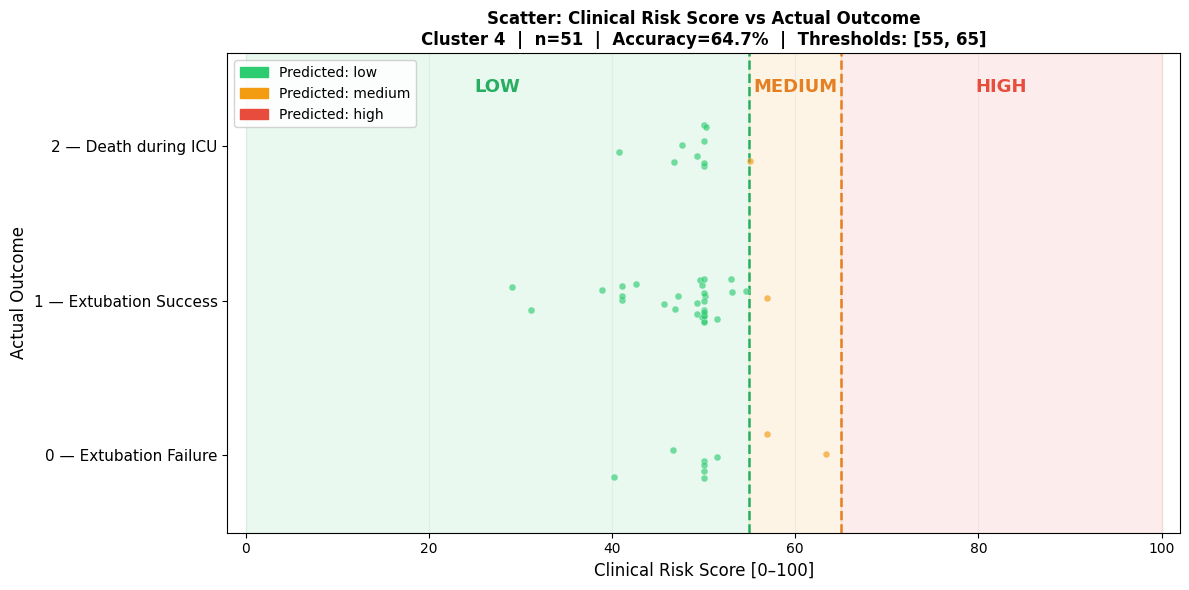

 Scatter Cluster 4 salvato in 'scatter_clinical_risk_cluster4.png'


In [19]:
# ============================================================
# CELL 18 – Cluster 4
# Clinical Risk Score vs Actual Outcome
# ============================================================

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# ── Cluster 4 variables ──
best_t1_c4 = best_t1   # ← soglia Low/Medium  Cluster 4
best_t2_c4 = best_t2   # ← soglia Medium/High Cluster 4
acc_f_c4   = accuracy_score(
    results_df_c4['outcome'],
    results_df_c4['predicted_class']
)

print('Cluster 4 variables ready.')
print(f'  → n patients : {len(results_df_c4)}')
print(f"   → t1         : {best_t1_c4}")
print(f"   → t2         : {best_t2_c4}")
print(f"   → Accuracy   : {acc_f_c4*100:.2f}%")

# ── Colour map for predicted class ──
color_map = {
    0: '#f39c12',   # Predicted: medium  → arancione
    1: '#2ecc71',   # Predicted: low  → verde
    2: '#e74c3c'    # Predicted: high   → rosso
}
label_map = {
    0: 'Predicted: medium',
    1: 'Predicted: low',
    2: 'Predicted: high'
}

# ── Figura ──
fig, ax = plt.subplots(figsize=(12, 6))

# --- Background zone shading ---
ax.axvspan(0,          best_t1_c4,
           color='#2ecc71', alpha=0.10, zorder=0)
ax.axvspan(best_t1_c4, best_t2_c4,
           color='#f39c12', alpha=0.10, zorder=0)
ax.axvspan(best_t2_c4, 100,
           color='#e74c3c', alpha=0.10, zorder=0)

# --- Threshold vertical lines ---
ax.axvline(x=best_t1_c4,
           color='#27ae60', linestyle='--',
           linewidth=1.8, zorder=1)
ax.axvline(x=best_t2_c4,
           color='#e67e22', linestyle='--',
           linewidth=1.8, zorder=1)

# --- Zone labels ---
ax.text(best_t1_c4 / 2,
        2.38, 'LOW',
        color='#27ae60', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)
ax.text((best_t1_c4 + best_t2_c4) / 2,
        2.38, 'MEDIUM',
        color='#e67e22', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)
ax.text((best_t2_c4 + 100) / 2,
        2.38, 'HIGH',
        color='#e74c3c', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)

# --- Scatter by predicted class ---
np.random.seed(42)
for pred_class in [1, 0, 2]:
    mask   = (results_df_c4['predicted_class']
               == pred_class)
    subset = results_df_c4[mask].reset_index(drop=True)
    jitter = np.random.uniform(
        -0.15, 0.15, size=len(subset)
    )
    ax.scatter(
        subset['clinical_risk'],
        subset['outcome'] + jitter,
        color=color_map[pred_class],
        label=label_map[pred_class],
        alpha=0.65,
        s=25,
        edgecolors='white',
        linewidths=0.3,
        zorder=3
    )

# --- Y-axis ---
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([
    '0 — Extubation Failure',
    '1 — Extubation Success',
    '2 — Death during ICU'
], fontsize=11)

# --- X-axis ---
ax.set_xlim([-2, 102])
ax.set_ylim([-0.5, 2.6])
ax.set_xlabel('Clinical Risk Score [0–100]',
              fontsize=12)
ax.set_ylabel('Actual Outcome', fontsize=12)

# --- Title ---
ax.set_title(
    f'Scatter: Clinical Risk Score vs Actual Outcome\n'
    f'Cluster 4  |  n={len(results_df_c4)}  |  '
    f'Accuracy={acc_f_c4*100:.1f}%  |  '
    f'Thresholds: [{best_t1_c4}, {best_t2_c4}]',
    fontsize=12, fontweight='bold'
)

# --- Legend ---
handles = [
    mpatches.Patch(color='#2ecc71',
                   label='Predicted: low'),
    mpatches.Patch(color='#f39c12',
                   label='Predicted: medium'),
    mpatches.Patch(color='#e74c3c',
                   label='Predicted: high'),
]
ax.legend(handles=handles, fontsize=10,
          loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.15, axis='x')

plt.tight_layout()
plt.savefig(output_dir / 'scatter_clinical_risk_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter Cluster 4 salvato in "
      "'scatter_clinical_risk_cluster4.png'")


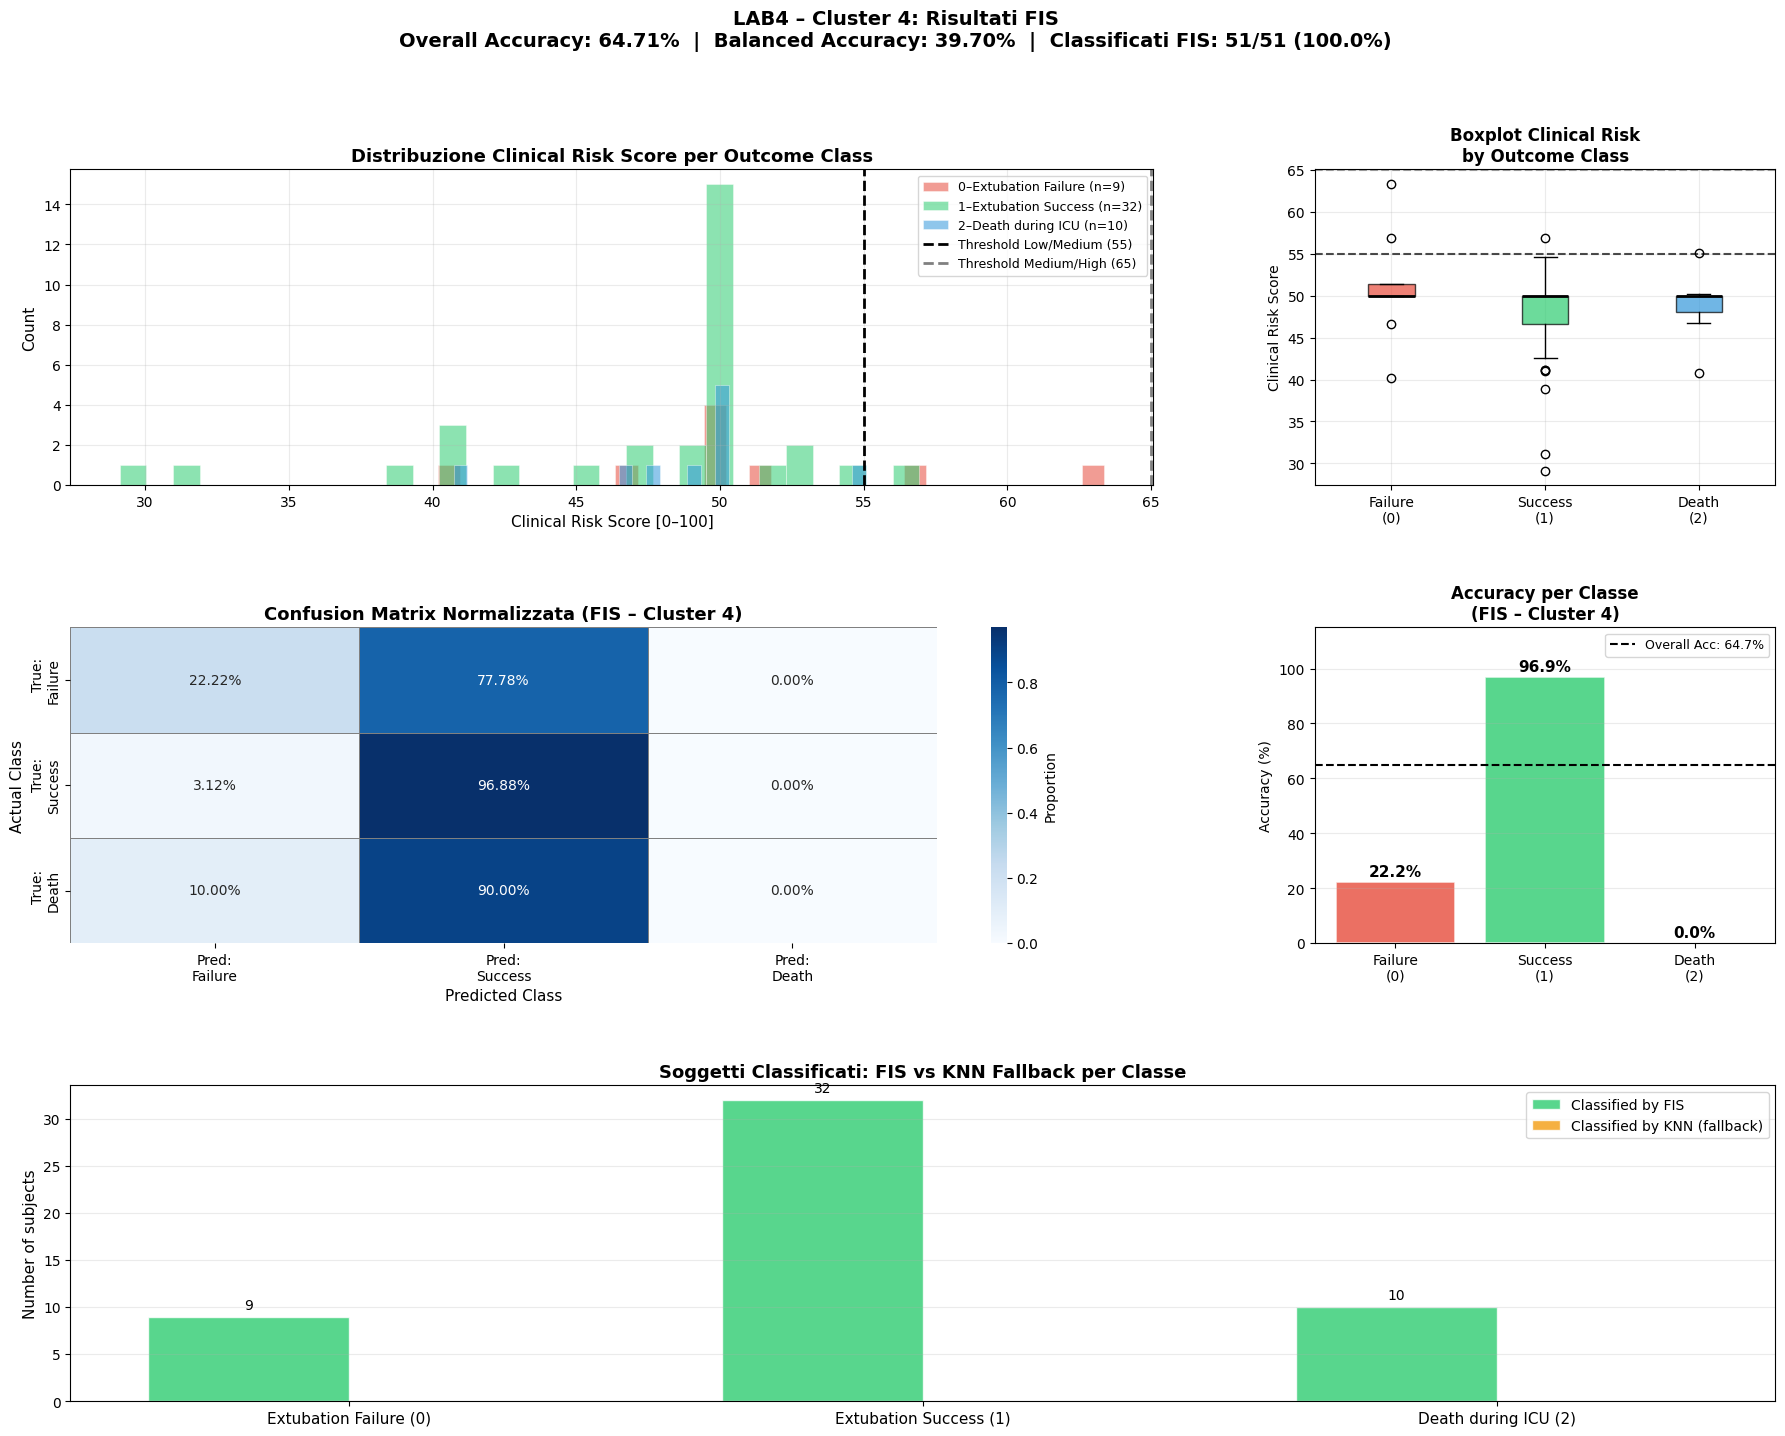

 Grafici salvati in 'FIS_results_cluster4.png'


In [20]:
# ============================================================
# CELL 19 – Cluster 4 – Results visualisation
# ============================================================

fig = plt.figure(figsize=(22, 16))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Plot 1: Distribuzione score ──
ax1 = fig.add_subplot(gs[0, :2])
for c in [0, 1, 2]:
    subset = results_df_c4[
        results_df_c4['outcome'] == c
    ]['clinical_risk']
    ax1.hist(subset, bins=30, alpha=0.55,
             color=colors_class[c],
             label=f'{labels_class[c]} (n={len(subset)})',
             edgecolor='white', linewidth=0.5)
ax1.axvline(x=best_t1, color='black', linestyle='--',
            linewidth=2,
            label=f'Threshold Low/Medium ({best_t1})')
ax1.axvline(x=best_t2, color='grey', linestyle='--',
            linewidth=2,
            label=f'Threshold Medium/High ({best_t2})')
ax1.set_title(
    'Distribuzione Clinical Risk Score '
    'per Outcome Class',
    fontsize=13, fontweight='bold'
)
ax1.set_xlabel('Clinical Risk Score [0–100]',
               fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# ── Plot 2: Boxplot ──
ax2 = fig.add_subplot(gs[0, 2])
data_box = [
    results_df_c4[
        results_df_c4['outcome'] == c
    ]['clinical_risk'].values
    for c in [0, 1, 2]
]
bp = ax2.boxplot(data_box, patch_artist=True,
                  medianprops=dict(color='black',
                                   linewidth=2))
for patch, c in zip(bp['boxes'], [0, 1, 2]):
    patch.set_facecolor(colors_class[c])
    patch.set_alpha(0.7)
ax2.axhline(y=best_t1, color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.axhline(y=best_t2, color='grey', linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.set_xticklabels(
    ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
    fontsize=10
)
ax2.set_title(
    'Boxplot Clinical Risk\nby Outcome Class',
    fontsize=12, fontweight='bold'
)
ax2.set_ylabel('Clinical Risk Score', fontsize=10)
ax2.grid(True, alpha=0.25)

# ── Plot 3: Confusion Matrix ──
ax3 = fig.add_subplot(gs[1, :2])
cm_norm_c4 = confusion_matrix(
    y_true_c4, y_pred_c4,
    labels=[0, 1, 2], normalize='true'
)
sns.heatmap(
    cm_norm_c4,
    annot=True, fmt='.2%',
    cmap='Blues', ax=ax3,
    xticklabels=['Pred:\nFailure',
                 'Pred:\nSuccess',
                 'Pred:\nDeath'],
    yticklabels=['True:\nFailure',
                 'True:\nSuccess',
                 'True:\nDeath'],
    linewidths=0.5, linecolor='grey',
    cbar_kws={'label': 'Proportion'}
)
ax3.set_title(
    'Confusion Matrix Normalizzata (FIS – Cluster 4)',
    fontsize=13, fontweight='bold'
)
ax3.set_xlabel('Predicted Class', fontsize=11)
ax3.set_ylabel('Actual Class', fontsize=11)

# ── Plot 4: Accuracy per classe ──
ax4 = fig.add_subplot(gs[1, 2])
per_class_acc_c4 = []
for c in [0, 1, 2]:
    mask  = y_true_c4 == c
    acc_c = accuracy_score(
        y_true_c4[mask], y_pred_c4[mask]
    )
    per_class_acc_c4.append(acc_c)

bars = ax4.bar(
    ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
    [a * 100 for a in per_class_acc_c4],
    color=[colors_class[c] for c in [0, 1, 2]],
    alpha=0.8, edgecolor='white', linewidth=1.2
)
for bar, acc_c in zip(bars, per_class_acc_c4):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{acc_c*100:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax4.axhline(y=acc_f * 100, color='black',
            linestyle='--', linewidth=1.5,
            label=f'Overall Acc: {acc_f*100:.1f}%')
ax4.set_title(
    'Accuracy per Classe\n(FIS – Cluster 4)',
    fontsize=12, fontweight='bold'
)
ax4.set_ylabel('Accuracy (%)', fontsize=10)
ax4.set_ylim([0, 115])
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25, axis='y')

# ── Plot 5: FIS vs KNN per classe ──
ax5 = fig.add_subplot(gs[2, :])
x     = np.arange(3)
width = 0.35

if 'knn_fallback' in results_df_c4.columns:
    n_fis_per_class = [
        (~results_df_c4['knn_fallback'] &
         (results_df_c4['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [
        (results_df_c4['knn_fallback'] &
         (results_df_c4['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
else:
    n_fis_per_class = [
        (results_df_c4['outcome'] == c).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [0, 0, 0]

bars1 = ax5.bar(x - width/2, n_fis_per_class, width,
                label='Classified by FIS',
                color='#2ecc71', alpha=0.8,
                edgecolor='white')
bars2 = ax5.bar(x + width/2, n_knn_per_class, width,
                label='Classified by KNN (fallback)',
                color='#f39c12', alpha=0.8,
                edgecolor='white')

for bar in bars1:
    if bar.get_height() > 0:
        ax5.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10
        )
for bar in bars2:
    if bar.get_height() > 0:
        ax5.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10
        )

ax5.set_xticks(x)
ax5.set_xticklabels([
    'Extubation Failure (0)',
    'Extubation Success (1)',
    'Death during ICU (2)'
], fontsize=11)
ax5.set_title(
    'Soggetti Classificati: FIS vs KNN Fallback '
    'per Classe',
    fontsize=13, fontweight='bold'
)
ax5.set_ylabel('Number of subjects', fontsize=11)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.25, axis='y')

n_fis_tot = sum(n_fis_per_class)
n_knn_tot = sum(n_knn_per_class)
n_tot_fig = len(results_df_c4)

fig.suptitle(
    f'LAB4 – Cluster 4: Risultati FIS\n'
    f'Overall Accuracy: {acc_f*100:.2f}%  |  '
    f'Balanced Accuracy: {bal_acc_f*100:.2f}%  |  '
    f'Classificati FIS: {n_fis_tot}/{n_tot_fig} '
    f'({n_fis_tot/n_tot_fig*100:.1f}%)',
    fontsize=14, fontweight='bold'
)
plt.savefig(output_dir / 'FIS_results_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Grafici salvati in 'FIS_results_cluster4.png'")


In [21]:
# ============================================================
# CELL 20 – CLUSTER 4 – Riepilogo Finale
# ============================================================

n_tot = len(results_df_c4)
if 'knn_fallback' in results_df_c4.columns:
    n_fis = (~results_df_c4['knn_fallback']).sum()
    n_knn = results_df_c4['knn_fallback'].sum()
else:
    n_fis = results_df_c4['clinical_risk'].notna().sum()
    n_knn = 0

print("=" * 65)
print("  RIEPILOGO FINALE – LAB4 CLUSTER 4")
print("=" * 65)
print(f"""
   Dataset
     → Soggetti Cluster 4     : {n_tot}
     → Feature selezionate    : {len(feature_cols_cluster4)}
     → Outcome classes        : 3
       • 0–Extubation Failure : {(y==0).sum()}
       • 1–Extubation Success : {(y==1).sum()}
       • 2–Death during ICU   : {(y==2).sum()}

   Fuzzy Inference System
     → Variabili input        : {len(feature_cols_cluster4)}
     → Variabili output       : 1 (clinical_risk)
     → Regole totali          : {len(rules_cluster4)}

   Performance
     → Overall Accuracy       : {acc_f*100:.2f}%
     → Balanced Accuracy      : {bal_acc_f*100:.2f}%
     → Classificati da FIS    : {n_fis} ({n_fis/n_tot*100:.1f}%)
     → Classificati da KNN    : {n_knn} ({n_knn/n_tot*100:.1f}%)
     → Soglia Low/Medium      : {best_t1}
     → Soglia Medium/High     : {best_t2}

   File salvati
     → histograms_cluster4.png
     → boxplots_cluster4.png
     → MF_continuous_cluster4.png
     → MF_binary_cluster4.png
     → dendrograms_cluster4.png
     → fuzzy_rules_cluster4.xlsx
     → FIS_results_cluster4.png
""")


  RIEPILOGO FINALE – LAB4 CLUSTER 4

   Dataset
     → Soggetti Cluster 4     : 51
     → Feature selezionate    : 4
     → Outcome classes        : 3
       • 0–Extubation Failure : 9
       • 1–Extubation Success : 32
       • 2–Death during ICU   : 10

   Fuzzy Inference System
     → Variabili input        : 4
     → Variabili output       : 1 (clinical_risk)
     → Regole totali          : 54

   Performance
     → Overall Accuracy       : 64.71%
     → Balanced Accuracy      : 39.70%
     → Classificati da FIS    : 51 (100.0%)
     → Classificati da KNN    : 0 (0.0%)
     → Soglia Low/Medium      : 55
     → Soglia Medium/High     : 65

   File salvati
     → histograms_cluster4.png
     → boxplots_cluster4.png
     → MF_continuous_cluster4.png
     → MF_binary_cluster4.png
     → dendrograms_cluster4.png
     → fuzzy_rules_cluster4.xlsx
     → FIS_results_cluster4.png

